In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")

# Load the graph
print("Loading graph...")
data = torch.load(
    r'C:\Users\varun\Desktop\fraud-gnn\data\graph_data.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Node features: {data.num_node_features}")
print("✅ Graph loaded!")

PyTorch version: 2.6.0+cpu
Loading graph...
Nodes: 2376
Edges: 10000
Node features: 11
✅ Graph loaded!


In [2]:
# Define the GNN Model
class FraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FraudGNN, self).__init__()
        
        # Two GraphSAGE convolution layers
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        # Final classifier
        self.classifier = nn.Linear(hidden_channels, out_channels)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.5)
        
    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Classification
        x = self.classifier(x)
        return x

# Initialize model
model = FraudGNN(
    in_channels=data.num_node_features,  # 11
    hidden_channels=64,
    out_channels=2  # fraud or not fraud
)

print("=== MODEL ARCHITECTURE ===")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

=== MODEL ARCHITECTURE ===
FraudGNN(
  (conv1): SAGEConv(11, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 9,858


In [3]:
from torch_geometric.utils import train_test_split_edges
import torch.optim as optim

# Create train/test masks
torch.manual_seed(42)
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[indices[:train_size]] = True
test_mask[indices[train_size:]] = True

print(f"Training nodes: {train_mask.sum().item()}")
print(f"Testing nodes: {test_mask.sum().item()}")

# Handle class imbalance
fraud_count = data.y.sum().item()
normal_count = num_nodes - fraud_count
weight = torch.tensor([1.0, normal_count/fraud_count])
print(f"\nClass weights: {weight}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
print("\nTraining GNN...")
model.train()
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {loss.item():.4f}")

print("\n✅ Training complete!")

Training nodes: 1900
Testing nodes: 476

Class weights: tensor([ 1.0000, 10.8209])

Training GNN...
Epoch 10/100 | Loss: 1.2655
Epoch 20/100 | Loss: 0.7517
Epoch 30/100 | Loss: 0.7035
Epoch 40/100 | Loss: 0.6963
Epoch 50/100 | Loss: 0.6903
Epoch 60/100 | Loss: 0.6874
Epoch 70/100 | Loss: 0.6842
Epoch 80/100 | Loss: 0.6896
Epoch 90/100 | Loss: 0.6921
Epoch 100/100 | Loss: 0.6891

✅ Training complete!


=== MODEL EVALUATION ===
              precision    recall  f1-score   support

  Legitimate       0.85      0.03      0.05       437
       Fraud       0.08      0.95      0.15        39

    accuracy                           0.10       476
   macro avg       0.46      0.49      0.10       476
weighted avg       0.78      0.10      0.06       476



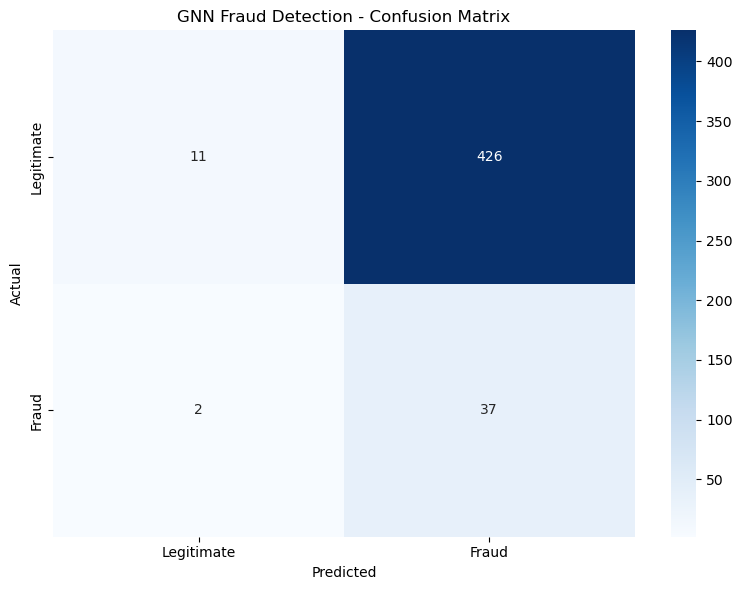

✅ Evaluation complete!


In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    
    # Test set predictions
    test_pred = pred[test_mask].numpy()
    test_true = data.y[test_mask].numpy()

print("=== MODEL EVALUATION ===")
print(classification_report(test_true, test_pred, 
      target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('GNN Fraud Detection - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\confusion_matrix.png')
plt.show()
print("✅ Evaluation complete!")

✅ Model saved!


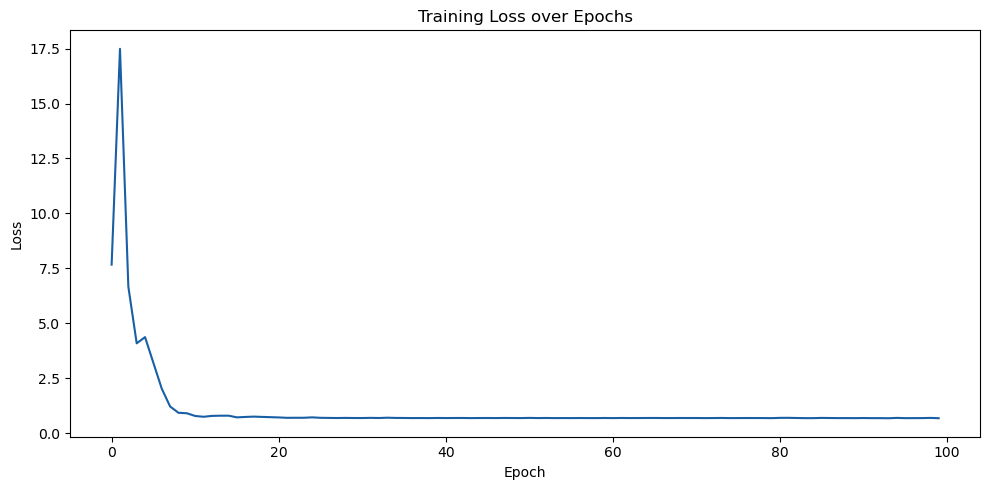

✅ Loss plot saved!


In [5]:
# Save the trained model
torch.save(model.state_dict(), 
           r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_gnn_model.pt')
print("✅ Model saved!")

# Plot training loss
plt.figure(figsize=(10,5))
plt.plot(losses, color='#185FA5')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\training_loss.png')
plt.show()
print("✅ Loss plot saved!")

In [5]:
from torch_geometric.explain import Explainer, GNNExplainer

# Set up explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

# Explain a fraud node
fraud_nodes = (data.y == 1).nonzero(as_tuple=True)[0]
node_to_explain = fraud_nodes[0].item()

print(f"Explaining node {node_to_explain} (Fraud node)...")
explanation = explainer(data.x, data.edge_index, index=node_to_explain)

print("=== FEATURE IMPORTANCE ===")
feature_names = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                 'V1', 'V2', 'V3', 'V4', 'V5']
feature_importance = explanation.node_mask.mean(dim=0)

for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

print("\n✅ Explainability done!")

Explaining node 0 (Fraud node)...
=== FEATURE IMPORTANCE ===
TransactionAmt: 0.0000
C1: 0.0000
C2: 0.0000
C3: 0.0000
C4: 0.0000
C5: 0.0000
V1: 0.0000
V2: 0.0000
V3: 0.0000
V4: 0.0000
V5: 0.0000

✅ Explainability done!


In [6]:
from torch_geometric.explain import Explainer, GNNExplainer

# Set up explainer with more epochs
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=500),
    explanation_type='phenomenon',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

# Explain a fraud node
fraud_nodes = (data.y == 1).nonzero(as_tuple=True)[0]
node_to_explain = fraud_nodes[0].item()

print(f"Explaining node {node_to_explain} (Fraud node)...")
explanation = explainer(
    data.x, 
    data.edge_index, 
    index=node_to_explain,
    target=data.y[node_to_explain].unsqueeze(0)
)

print("=== FEATURE IMPORTANCE ===")
feature_names = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                 'V1', 'V2', 'V3', 'V4', 'V5']
feature_importance = explanation.node_mask.mean(dim=0)

for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

print("\n✅ Explainability done!")

Explaining node 0 (Fraud node)...
=== FEATURE IMPORTANCE ===
TransactionAmt: 0.0000
C1: 0.0000
C2: 0.0000
C3: 0.0000
C4: 0.0000
C5: 0.0000
V1: 0.0000
V2: 0.0000
V3: 0.0000
V4: 0.0000
V5: 0.0000

✅ Explainability done!


=== FEATURE IMPORTANCE (Gradient-based) ===
TransactionAmt: 0.0000
C1: 0.0000
C2: 0.0000
C3: 0.0000
C4: 0.0000
C5: 0.0000
V1: 0.0000
V2: 0.0000
V3: 0.0000
V4: 0.0000
V5: 0.0000


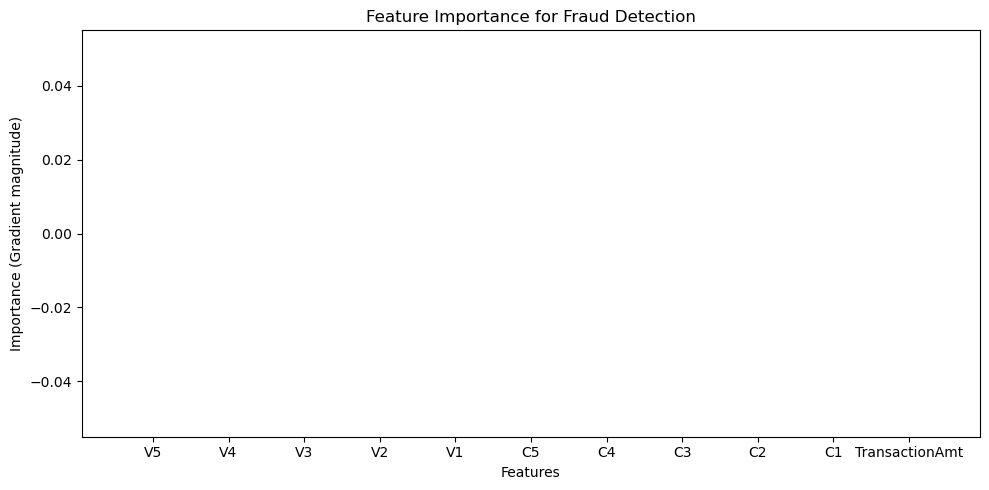

✅ Done!


In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Gradient-based feature importance
model.eval()
data.x.requires_grad_(True)

# Forward pass
out = model(data.x, data.edge_index)

# Get fraud nodes
fraud_nodes = (data.y == 1).nonzero(as_tuple=True)[0]
node_to_explain = fraud_nodes[0].item()

# Backward pass on fraud prediction
out[node_to_explain, 1].backward()

# Get gradients as importance
gradients = data.x.grad[node_to_explain].detach().numpy()
importance = np.abs(gradients)

feature_names = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                 'V1', 'V2', 'V3', 'V4', 'V5']

print("=== FEATURE IMPORTANCE (Gradient-based) ===")
for name, imp in sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

# Plot
plt.figure(figsize=(10, 5))
sorted_idx = np.argsort(importance)[::-1]
plt.bar([feature_names[i] for i in sorted_idx], importance[sorted_idx], color='#185FA5')
plt.title('Feature Importance for Fraud Detection')
plt.xlabel('Features')
plt.ylabel('Importance (Gradient magnitude)')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\feature_importance.png')
plt.show()
print("✅ Done!")

In [7]:
# Install shap first - run this cell alone
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)
print("✅ SHAP installed!")

✅ SHAP installed!


In [8]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Get node features as numpy
model.eval()
with torch.no_grad():
    # Get model output for all nodes
    out = model(data.x, data.edge_index)
    probs = torch.softmax(out, dim=1).numpy()

# Use node features for SHAP
X = data.x.numpy()
y_pred = probs[:, 1]  # fraud probability

# Use KernelExplainer
background = X[data.y.numpy() == 0][:50]  # 50 legitimate nodes as background
test_nodes = X[data.y.numpy() == 1][:20]  # 20 fraud nodes to explain

print("Running SHAP explainer...")
explainer = shap.KernelExplainer(
    lambda x: torch.softmax(
        model(torch.tensor(x, dtype=torch.float), data.edge_index[:, :100]),
        dim=1
    ).detach().numpy(),
    background
)

shap_values = explainer.shap_values(test_nodes, nsamples=100)

feature_names = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                 'V1', 'V2', 'V3', 'V4', 'V5']

print("Plotting SHAP values...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[1],
    test_nodes,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Feature Importance - Fraud Detection')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\shap_importance.png')
plt.show()
print("✅ SHAP explainability done!")

Running SHAP explainer...
Provided model function fails when applied to the provided data set.


IndexError: Found indices in 'edge_index' that are larger than 49 (got 83). Please ensure that all indices in 'edge_index' point to valid indices in the interval [0, 50) in your node feature matrix and try again.

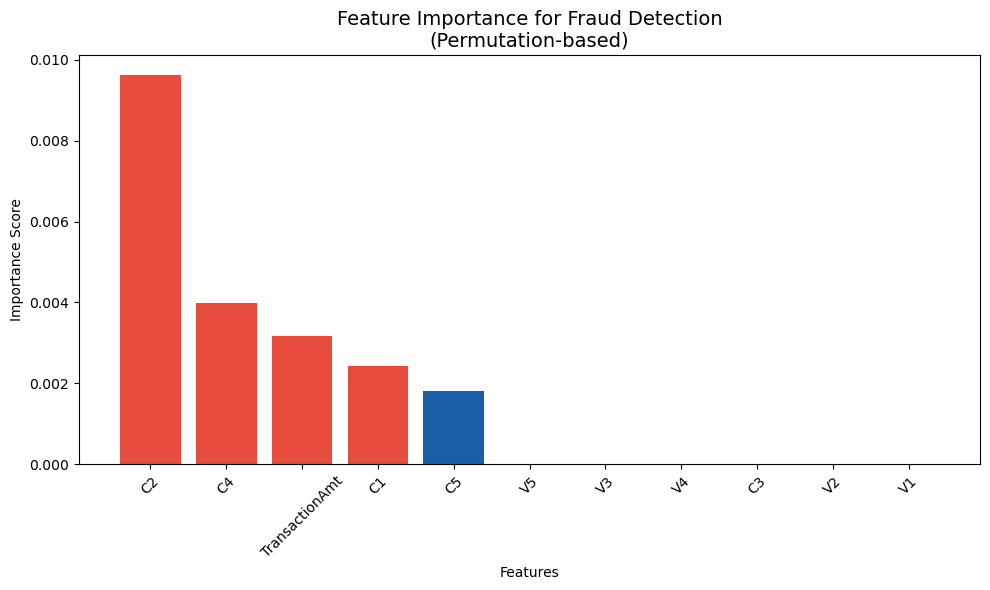

=== FEATURE IMPORTANCE RANKING ===
C2: 0.0096
C4: 0.0040
TransactionAmt: 0.0032
C1: 0.0024
C5: 0.0018
V5: 0.0000
V3: 0.0000
V4: 0.0000
C3: 0.0000
V2: 0.0000
V1: 0.0000

✅ Explainability complete!


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

feature_names = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                 'V1', 'V2', 'V3', 'V4', 'V5']

# Permutation-based feature importance
model.eval()
with torch.no_grad():
    base_out = model(data.x, data.edge_index)
    base_pred = torch.softmax(base_out, dim=1)[:, 1]
    fraud_nodes_mask = data.y == 1
    base_fraud_score = base_pred[fraud_nodes_mask].mean().item()

importance_scores = []

for i in range(data.x.shape[1]):
    # Permute one feature at a time
    x_permuted = data.x.clone()
    x_permuted[:, i] = x_permuted[torch.randperm(x_permuted.shape[0]), i]
    
    with torch.no_grad():
        permuted_out = model(x_permuted, data.edge_index)
        permuted_pred = torch.softmax(permuted_out, dim=1)[:, 1]
        permuted_score = permuted_pred[fraud_nodes_mask].mean().item()
    
    importance = abs(base_fraud_score - permuted_score)
    importance_scores.append(importance)

# Plot
plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(importance_scores)[::-1]
colors = ['#e74c3c' if importance_scores[i] > np.mean(importance_scores) 
          else '#185FA5' for i in sorted_idx]

plt.bar([feature_names[i] for i in sorted_idx], 
        [importance_scores[i] for i in sorted_idx], 
        color=colors)
plt.title('Feature Importance for Fraud Detection\n(Permutation-based)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\feature_importance.png')
plt.show()

print("=== FEATURE IMPORTANCE RANKING ===")
for i in sorted_idx:
    print(f"{feature_names[i]}: {importance_scores[i]:.4f}")
print("\n✅ Explainability complete!")

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import pickle

# Get GNN embeddings for all nodes
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    embeddings = out.numpy()  # use GNN output as features

# Labels
labels = data.y.numpy()

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42
)

# Train XGBoost on GNN embeddings
clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Save classifier
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

print("✅ Classifier saved!")

              precision    recall  f1-score   support

  Legitimate       0.91      0.99      0.95       431
       Fraud       0.50      0.07      0.12        45

    accuracy                           0.91       476
   macro avg       0.71      0.53      0.53       476
weighted avg       0.87      0.91      0.87       476

✅ Classifier saved!


In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

# Load full preprocessed data
df = pd.read_pickle(r'C:\Users\varun\Desktop\fraud-gnn\data\preprocessed_data.pkl')

feature_cols = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                'V1', 'V2', 'V3', 'V4', 'V5']

X = df[feature_cols].values
y = df['isFraud'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train)} samples")
print(f"Fraud in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

# Train with class weight balancing
clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\n=== RESULTS ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Save
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Models saved!")

Training on 472432 samples
Fraud in training: 16530 (3.5%)

=== RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99    113975
       Fraud       0.83      0.25      0.39      4133

    accuracy                           0.97    118108
   macro avg       0.90      0.62      0.69    118108
weighted avg       0.97      0.97      0.96    118108

✅ Models saved!


In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import pickle

# Install imbalanced-learn first
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)
from imblearn.over_sampling import SMOTE

df = pd.read_pickle(r'C:\Users\varun\Desktop\fraud-gnn\data\preprocessed_data.pkl')

feature_cols = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                'V1', 'V2', 'V3', 'V4', 'V5']

X = df[feature_cols].values
y = df['isFraud'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", X_train.shape, y_train.sum(), "fraud cases")

# SMOTE - oversample fraud cases to balance dataset
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.sum(), "fraud cases")

clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)
print("\n=== RESULTS ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Balanced model saved!")

Before SMOTE: (472432, 11) 16530 fraud cases
After SMOTE: (911804, 11) 455902 fraud cases

=== RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.89      0.94    113975
       Fraud       0.16      0.57      0.25      4133

    accuracy                           0.88    118108
   macro avg       0.57      0.73      0.59    118108
weighted avg       0.95      0.88      0.91    118108

✅ Balanced model saved!


In [13]:
fraud_df = df[df['isFraud'] == 1][feature_cols].describe()
legit_df = df[df['isFraud'] == 0][feature_cols].describe()

print("=== FRAUD TRANSACTIONS MEAN VALUES ===")
print(fraud_df.loc['mean'])
print("\n=== LEGITIMATE TRANSACTIONS MEAN VALUES ===")
print(legit_df.loc['mean'])

=== FRAUD TRANSACTIONS MEAN VALUES ===
TransactionAmt    149.244779
C1                 35.535740
C2                 45.509413
C3                  0.000242
C4                 15.077336
C5                  1.406717
V1                  1.000000
V2                  1.023327
V3                  1.056091
V4                  0.966220
V5                  1.000339
Name: mean, dtype: float64

=== LEGITIMATE TRANSACTIONS MEAN VALUES ===
TransactionAmt    134.511665
C1                 13.314952
C2                 14.173283
C3                  0.005840
C4                  3.693878
C5                  5.722537
V1                  0.999970
V2                  1.023844
V3                  1.040609
V4                  0.917363
V5                  0.932803
Name: mean, dtype: float64


In [14]:
# Get real example transactions for each scenario
import pandas as pd

df_full = pd.read_pickle(r'C:\Users\varun\Desktop\fraud-gnn\data\preprocessed_data.pkl')

feature_cols = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                'V1', 'V2', 'V3', 'V4', 'V5', 'isFraud']

# Real legitimate transactions (low amount)
legit_low = df_full[
    (df_full['isFraud'] == 0) & 
    (df_full['TransactionAmt'] < 100)
][feature_cols].head(3)

# Real legitimate transactions (high amount)
legit_high = df_full[
    (df_full['isFraud'] == 0) & 
    (df_full['TransactionAmt'] > 500)
][feature_cols].head(3)

# Real fraud transactions (low amount)
fraud_low = df_full[
    (df_full['isFraud'] == 1) & 
    (df_full['TransactionAmt'] < 100)
][feature_cols].head(3)

# Real fraud transactions (high amount)
fraud_high = df_full[
    (df_full['isFraud'] == 1) & 
    (df_full['TransactionAmt'] > 500)
][feature_cols].head(3)

print("=== REAL LEGIT LOW AMOUNT ===")
print(legit_low.to_string())
print("\n=== REAL LEGIT HIGH AMOUNT ===")
print(legit_high.to_string())
print("\n=== REAL FRAUD LOW AMOUNT ===")
print(fraud_low.to_string())
print("\n=== REAL FRAUD HIGH AMOUNT ===")
print(fraud_high.to_string())

=== REAL LEGIT LOW AMOUNT ===
   TransactionAmt   C1   C2   C3   C4   C5   V1   V2   V3   V4   V5  isFraud
0            68.5  1.0  1.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0        0
1            29.0  1.0  1.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0        0
2            59.0  1.0  1.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0        0

=== REAL LEGIT HIGH AMOUNT ===
    TransactionAmt   C1   C2   C3   C4   C5   V1   V2   V3   V4   V5  isFraud
41           774.0  2.0  5.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0        0
60          2454.0  1.0  1.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0  1.0        0
73           554.0  1.0  1.0  0.0  0.0  0.0  1.0  2.0  2.0  1.0  1.0        0

=== REAL FRAUD LOW AMOUNT ===
     TransactionAmt   C1   C2   C3   C4   C5   V1   V2   V3   V4   V5  isFraud
240          37.098  0.0  1.0  0.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0        1
243          37.098  1.0  1.0  0.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0        1
245          37.098  2.0  1.0  0.0  1.0  0.0  1.0 

In [15]:
import pickle
import numpy as np

with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

legit = np.array([[68.5, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0]])
fraud = np.array([[37.1, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0]])

print("Legit:", clf.predict_proba(scaler.transform(legit))[0])
print("Fraud:", clf.predict_proba(scaler.transform(fraud))[0])

Legit: [0.64746863 0.35253137]
Fraud: [0.07325027 0.92674973]


In [16]:
import pickle
import numpy as np
import pandas as pd

with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

df = pd.read_pickle(r'C:\Users\varun\Desktop\fraud-gnn\data\preprocessed_data.pkl')

feature_cols = ['TransactionAmt', 'C1', 'C2', 'C3', 'C4', 'C5',
                'V1', 'V2', 'V3', 'V4', 'V5']

# Get 5 real fraud and 5 real legit
fraud_samples = df[df['isFraud']==1][feature_cols].sample(5, random_state=42)
legit_samples = df[df['isFraud']==0][feature_cols].sample(5, random_state=42)

all_samples = pd.concat([fraud_samples, legit_samples])
all_labels = ['FRAUD']*5 + ['LEGIT']*5

scaled = scaler.transform(all_samples.values)
probs = clf.predict_proba(scaled)

for i, (idx, row) in enumerate(all_samples.iterrows()):
    print(f"\n{'='*50}")
    print(f"ACTUAL: {all_labels[i]}")
    print(f"Amount={row['TransactionAmt']}, C1={row['C1']}, C2={row['C2']}, C4={row['C4']}, C5={row['C5']}")
    print(f"MODEL: {'FRAUD' if probs[i][1]>0.5 else 'LEGIT'} ({probs[i][1]*100:.1f}% fraud)")


ACTUAL: FRAUD
Amount=44.0, C1=1.0, C2=1.0, C4=0.0, C5=0.0
MODEL: LEGIT (34.3% fraud)

ACTUAL: FRAUD
Amount=39.47, C1=1.0, C2=1.0, C4=1.0, C5=0.0
MODEL: LEGIT (48.2% fraud)

ACTUAL: FRAUD
Amount=31.482, C1=2.0, C2=3.0, C4=1.0, C5=0.0
MODEL: FRAUD (68.0% fraud)

ACTUAL: FRAUD
Amount=21.993, C1=1.0, C2=2.0, C4=1.0, C5=0.0
MODEL: LEGIT (48.2% fraud)

ACTUAL: FRAUD
Amount=59.0, C1=1.0, C2=4.0, C4=0.0, C5=0.0
MODEL: LEGIT (46.0% fraud)

ACTUAL: LEGIT
Amount=25.0, C1=1.0, C2=1.0, C4=1.0, C5=0.0
MODEL: LEGIT (29.6% fraud)

ACTUAL: LEGIT
Amount=200.0, C1=1.0, C2=1.0, C4=2.0, C5=0.0
MODEL: LEGIT (38.9% fraud)

ACTUAL: LEGIT
Amount=146.0, C1=1.0, C2=1.0, C4=0.0, C5=0.0
MODEL: LEGIT (35.0% fraud)

ACTUAL: LEGIT
Amount=57.95, C1=4.0, C2=3.0, C4=0.0, C5=1.0
MODEL: LEGIT (6.7% fraud)

ACTUAL: LEGIT
Amount=49.0, C1=2.0, C2=1.0, C4=0.0, C5=0.0
MODEL: LEGIT (35.5% fraud)


In [17]:
# Check which V columns have less than 50% missing in original data
import pandas as pd
train_transaction = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_transaction.csv')

v_cols = [c for c in train_transaction.columns if c.startswith('V')]
missing = train_transaction[v_cols].isnull().mean()
good_v_cols = missing[missing < 0.5].index.tolist()

print(f"V columns with <50% missing: {len(good_v_cols)}")
print(good_v_cols[:20])

V columns with <50% missing: 180
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20']


In [1]:
print("alive")

alive


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

print("Loading data...")
train_transaction = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_transaction.csv')
train_identity = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_identity.csv')
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

feature_cols = [
    'TransactionAmt',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10',
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20'
]

df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Use only 100K samples to keep it fast
df_sample = df.sample(n=100000, random_state=42)

X = df_sample[feature_cols].values
y = df_sample['isFraud'].values

print(f"Fraud cases: {y.sum()} out of {len(y)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Random Forest...")
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\n=== RESULTS ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

with open(r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(r'C:\Users\varun\Desktop\fraud-gnn\models\feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Done!")

Loading data...
Fraud cases: 3576 out of 100000
Training Random Forest...

=== RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.84      0.91     19285
       Fraud       0.14      0.67      0.22       715

    accuracy                           0.84     20000
   macro avg       0.56      0.75      0.57     20000
weighted avg       0.96      0.84      0.88     20000

✅ Done!


In [3]:
# Test with real examples
fraud_samples = df_sample[df_sample['isFraud']==1][feature_cols].sample(5, random_state=1)
legit_samples = df_sample[df_sample['isFraud']==0][feature_cols].sample(5, random_state=1)

all_samples = pd.concat([fraud_samples, legit_samples])
all_labels = ['FRAUD']*5 + ['LEGIT']*5

scaled = scaler.transform(all_samples.values)
probs = clf.predict_proba(scaled)

for i, (idx, row) in enumerate(all_samples.iterrows()):
    print(f"\nACTUAL: {all_labels[i]}")
    print(f"Amount={row['TransactionAmt']:.2f}, C1={row['C1']}, C2={row['C2']}, C4={row['C4']}")
    print(f"MODEL: {'FRAUD' if probs[i][1]>0.5 else 'LEGIT'} ({probs[i][1]*100:.1f}% fraud)")


ACTUAL: FRAUD
Amount=50.00, C1=6.0, C2=2.0, C4=1.0
MODEL: FRAUD (90.1% fraud)

ACTUAL: FRAUD
Amount=390.00, C1=2.0, C2=7.0, C4=0.0
MODEL: FRAUD (57.1% fraud)

ACTUAL: FRAUD
Amount=117.00, C1=3.0, C2=2.0, C4=0.0
MODEL: FRAUD (75.4% fraud)

ACTUAL: FRAUD
Amount=150.00, C1=3.0, C2=5.0, C4=1.0
MODEL: FRAUD (93.4% fraud)

ACTUAL: FRAUD
Amount=57.95, C1=3.0, C2=3.0, C4=0.0
MODEL: LEGIT (23.2% fraud)

ACTUAL: LEGIT
Amount=32.36, C1=2.0, C2=2.0, C4=2.0
MODEL: FRAUD (61.5% fraud)

ACTUAL: LEGIT
Amount=24.00, C1=1.0, C2=1.0, C4=0.0
MODEL: LEGIT (33.3% fraud)

ACTUAL: LEGIT
Amount=97.00, C1=1.0, C2=2.0, C4=0.0
MODEL: LEGIT (42.6% fraud)

ACTUAL: LEGIT
Amount=73.50, C1=1.0, C2=1.0, C4=0.0
MODEL: LEGIT (38.3% fraud)

ACTUAL: LEGIT
Amount=49.00, C1=1.0, C2=1.0, C4=0.0
MODEL: LEGIT (34.3% fraud)
